<a href="https://colab.research.google.com/github/saradom11/Simulacion-II/blob/main/Caminata_Aleatoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div style="text-align:center; background-color:#F3E5F5; padding:22px; border-radius:14px;">
<font face="Georgia" size="6" color="#6A1B9A"><b>Caminata aleatoria sobre un grafo</b></font><br>

**Materia:** Simulación II

**Alumna:** Arredondo Domínguez Sara Itzel

---
<font face="Georgia" size="5" color="#7B1FA2"><b>1. Planteamiento del problema</b></font>

Consideremos una secuencia de $0^S$ y $1^S$ de longitud $m$:

$x=(x_1,x_2,\ldots,x_m),\qquad x_i\in\{0,1\}$

Llamaremos **buena cadena** a aquella que no contiene dos $1^s$ adyacentes. La pregunta es:

<font face="Arial" size="4" color="#6A1B9A"><b>La pregunta a resolver es: ¿Cuál es el número esperado de $1^s$ si todas las buenas cadenas son igual de probables?</b></font>

Si $r(x)$ representa el número de unos de la cadena $x$, buscamos:

$$\boxed{\mu=\mathbb{E}[r(X)]} ≈ \frac{r(Y_0) + r(Y_1) + ... + rY(n)}{n} $$

donde $X$ se selecciona uniformemente del conjunto de buenas cadenas de longitud $m$.


---
<font face="Georgia" size="5" color="#7B1FA2"><b>2. Visto en clase: \(m=4\)</b></font>

Las buenas cadenas son:

$0000,\ 1000,\ 0100,\ 0010,\ 0001,\ 1010,\ 0101,\ 1001$

Hay $8$ buenas cadenas. Sus cantidades de unos son $0,1,1,1,1,2,2,2$. Entonces:

$\mu=\frac{1}{8}(0+1+1+1+1+2+2+2)=\boxed{1.25}$

Este valor servirá para comprobar el resultado de la simulación.


---
<font face="Georgia" size="5" color="#7B1FA2"><b>3. ¿Por qué usar una caminata aleatoria?</b></font>

Para $m=100:$
Habría $2^{100} \approx 10^{30}$

$$ 2^{10} =1024 $$
$$ (2^{10} \approx 10^3 )10$$
$$2^{100} \approx 10^{30}$$

Y hay solamente $10^{21}$ buenas cadenas la proporción es $ \frac{10^{21}}{10^{30}}= 10^{-9}$ es decir vamos a encontrar una buena cadena da mil millones, lo que muestra que el procedimiento no es viable.

Enumerar todas las cadenas se vuelve impráctico cuando $m$ crece. Usaremos **Monte Carlo mediante cadenas de Markov**: la caminata se mueve entre buenas cadenas y el promedio de los estados visitados aproxima el valor esperado.


---
<font face="Georgia" size="5" color="#7B1FA2"><b>4. Importación de librerías</b></font>

**NumPy** permite manejar arreglos y generar números aleatorios; **Matplotlib** crea gráficas y **NetworkX** representa el grafo.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Configuramos una presentación visual en tonos morados
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["font.family"] = "DejaVu Sans"

# La semilla permite reproducir la misma secuencia aleatoria
np.random.seed(2026)


---
<font face="Georgia" size="5" color="#7B1FA2"><b>5. Funciones auxiliares</b></font>

Definimos una función que verifica si una cadena es buena y otra que cuenta sus unos.


In [5]:
def es_buena(cadena):   # Devuelve True si no hay dos unos consecutivos
    # Recorremos los pares de posiciones adyacentes
    for i in range(len(cadena) - 1):
        if cadena[i] == 1 and cadena[i + 1] == 1:
            return False
    return True
def contar_unos(cadena):   #Devuelve el número de unos de la cadena
    # np.sum suma los valores 0 y 1; por tanto cuenta los unos
    return int(np.sum(cadena))

print("¿0101 es buena?", es_buena([0, 1, 0, 1]))
print("¿0110 es buena?", es_buena([0, 1, 1, 0]))
print("Unos en 1010:", contar_unos([1, 0, 1, 0]))


¿0101 es buena? True
¿0110 es buena? False
Unos en 1010: 2


---
<font face="Georgia" size="5" color="#7B1FA2"><b>6. Código de la caminata aleatoria</b></font>

El siguiente algoritmo implementa la cadena de Markov. El siguiente estado depende del estado actual y de la posición seleccionada al azar.


In [6]:
# Simula una caminata aleatoria sobre las buenas cadenas y devuelve todos los estados visitados
# m: longitud de la cadena
# n_pasos: número de movimientos propuestos
# estado_inicial: buena cadena opcional; por defecto se usan ceros

def caminata_aleatoria(m, n_pasos=100_000, estado_inicial=None):
    # La cadena formada solo por ceros siempre es buena
    if estado_inicial is None:
        actual = np.zeros(m, dtype=int)
    else:
        actual = np.array(estado_inicial, dtype=int).copy()
        if len(actual) != m or not es_buena(actual):
            raise ValueError("El estado inicial debe ser una buena cadena de longitud m.")

    # Cada fila guardará un estado; hay n_pasos + 1 por incluir el inicial
    estados = np.zeros((n_pasos + 1, m), dtype=int)
    estados[0] = actual

    for t in range(1, n_pasos + 1):
        # randint(0,m) elige una posición entre 0 y m-1
        posicion = np.random.randint(0, m)

        # Copiamos la cadena y cambiamos 0 por 1 o 1 por 0
        propuesta = actual.copy()
        propuesta[posicion] = 1 - propuesta[posicion]

        # Aceptamos solo si la cadena propuesta sigue siendo buena
        # Si no lo es, se permanece en la actual
        if es_buena(propuesta):
            actual = propuesta

        # Guardamos el movimiento, aunque el nuevo movimiento no se haya aceptado
        estados[t] = actual

    return estados


# Prueba corta para m=4
prueba = caminata_aleatoria(m=4, n_pasos=20)
print("Primeros estados visitados:")
for estado in prueba[:10]:
    print("".join(map(str, estado)))

Primeros estados visitados:
0000
0100
0100
0100
0100
0000
0100
0000
1000
0000


---
<font face="Georgia" size="5" color="#7B1FA2"><b>7. Estimación Monte Carlo</b></font>

Sea $Y_t$ el estado visitado en el paso $t$, y sea $r(Y_t)$ su número de unos. La esperanza sería:

$\mu_n=\frac{1}{n}\sum_{t=1}^{n}r(Y_t)$

Descartamos los primeros estados como periodo de calentamiento (*burn-in*) para reducir la influencia del estado inicial.


In [7]:
def estimar_esperanza(m, n_pasos=100_000, burn_in=5_000): #Estima el número esperado de unos para cadenas de longitud m

    if burn_in < 0 or burn_in >= n_pasos:
        raise ValueError("burn_in debe ser >= 0 y menor que n_pasos")

    estados = caminata_aleatoria(m, n_pasos)
    unos_por_estado = np.sum(estados, axis=1)  # axis=1 indica que sumamos por fila: obtenemos unos por estado
    muestra_util = unos_por_estado[burn_in + 1:]  # Quitamos el estado inicial y el periodo de calentamiento
    estimacion = np.mean(muestra_util)  # La media de los conteos observados estima la esperanza
    return estimacion, muestra_util, estados


# Para m=4, contrastamos la simulación con el valor exacto 1.25
estimacion_4, muestra_4, estados_4 = estimar_esperanza(
    m=4, n_pasos=100_000, burn_in=5_000
)

print(f"Estimación Monte Carlo para m=4: {estimacion_4:.5f}")
print("Valor exacto para m=4: 1.25")
print(f"Error absoluto: {abs(estimacion_4 - 1.25):.5f}")


Estimación Monte Carlo para m=4: 1.25137
Valor exacto para m=4: 1.25
Error absoluto: 0.00137


---
<font face="Georgia" size="5" color="#7B1FA2"><b>8. Grafo de buenas cadenas para \(m=4\)</b></font>

Para $m=4$, el grafo es pequeño y podemos mostrar todos sus vértices. Las etiquetas son las cadenas buenas; las aristas conectan cadenas que difieren en una posición. Los lazos representan propuestas no válidas.


/tmp/ipykernel_3729/688142161.py:44: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(G4, pos, edgelist=lazos,


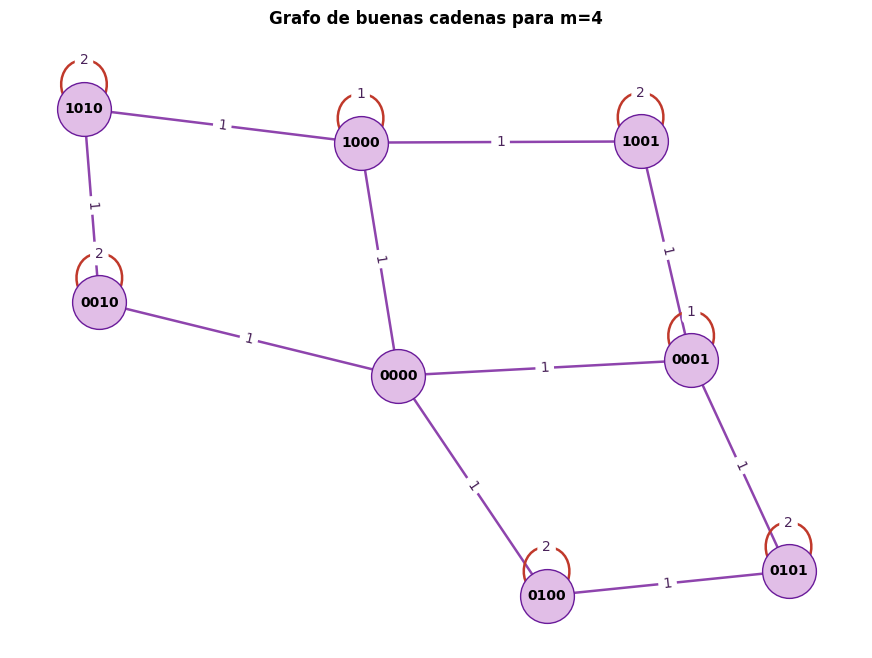

Número de vértices (buenas cadenas): 8


In [8]:
def construir_grafo_buenas(m):  # Construye el grafo considerando las buenas cadenas
    vertices = []
    # Recorremos los enteros de 0 a 2^m-1 y los escribimos en binario
    for numero in range(2**m):
        cadena = format(numero, f"0{m}b")
        if es_buena([int(bit) for bit in cadena]):
            vertices.append(cadena)

    G = nx.Graph()
    G.add_nodes_from(vertices)

    for vertice in vertices:
        cadena = [int(bit) for bit in vertice]
        for j in range(m):
            propuesta = cadena.copy()
            propuesta[j] = 1 - propuesta[j]
            vecino = "".join(map(str, propuesta))

            if es_buena(propuesta):
                if vecino != vertice:
                    G.add_edge(vertice, vecino, weight=1)
            else:
                # Cada propuesta inválida añade 1 al peso del lazo
                peso = G.get_edge_data(vertice, vertice, {}).get("weight", 0)
                G.add_edge(vertice, vertice, weight=peso + 1)

    return G


G4 = construir_grafo_buenas(4)
pos = nx.spring_layout(G4, seed=12)

plt.figure(figsize=(11, 8))
nx.draw_networkx_nodes(G4, pos, node_color="#E1BEE7",
                       edgecolors="#6A1B9A", node_size=1500)
nx.draw_networkx_labels(G4, pos, font_size=10, font_weight="bold")

aristas = [(u, v) for u, v in G4.edges() if u != v]
nx.draw_networkx_edges(G4, pos, edgelist=aristas,
                       edge_color="#8E44AD", width=1.8)

# Dibujamos los lazos aparte para destacarlos
lazos = [(u, v) for u, v in G4.edges() if u == v]
nx.draw_networkx_edges(G4, pos, edgelist=lazos,
                       edge_color="#C0392B", connectionstyle="arc3,rad=0.35",
                       width=1.8)

pesos = {(u, v): d["weight"] for u, v, d in G4.edges(data=True)}
nx.draw_networkx_edge_labels(G4, pos, edge_labels=pesos,
                             font_color="#4A235A", font_size=10)

plt.title("Grafo de buenas cadenas para m=4", fontweight="bold")
plt.axis("off")
plt.show()

print("Número de vértices (buenas cadenas):", G4.number_of_nodes())


---
<font face="Georgia" size="5" color="#7B1FA2"><b>9. Convergencia de la estimación</b></font>

El promedio acumulado permite observar cómo cambia la estimación conforme aumenta la cantidad de estados simulados. Esperamos que se estabilice alrededor del valor exacto \(1.25\) para \(m=4\).


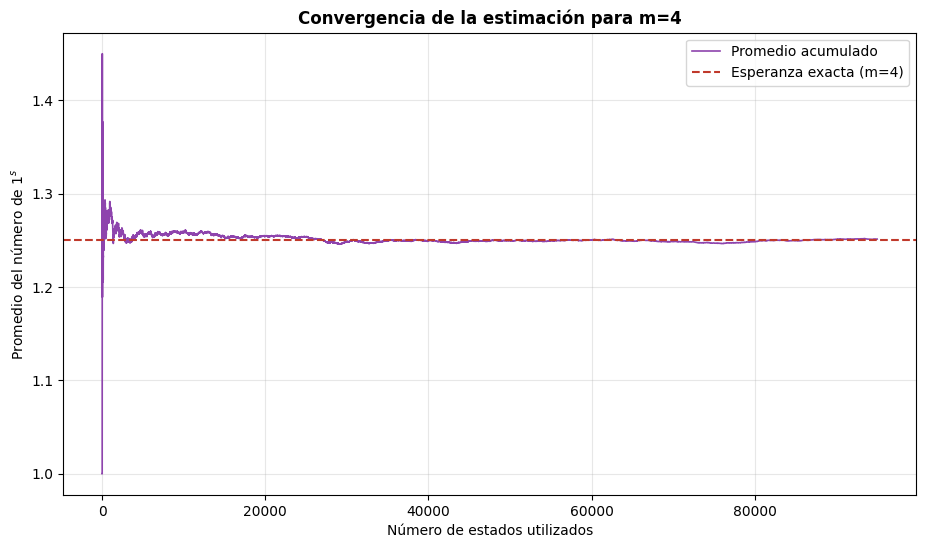

In [12]:
# Definimos el valor exacto teórico para m=4
esperanza_exacta_m4 = 1.25

# cumsum calcula sumas acumuladas; dividimos por 1,2,3,...,n
promedio_acumulado = np.cumsum(muestra_4) / np.arange(1, len(muestra_4) + 1)

plt.figure(figsize=(11, 6))
plt.plot(promedio_acumulado, color="#8E44AD", linewidth=1.2,
         label="Promedio acumulado")
plt.axhline(esperanza_exacta_m4, color="#C0392B", linestyle="--",
            label="Esperanza exacta (m=4)")
plt.xlabel("Número de estados utilizados")
plt.ylabel("Promedio del número de $1^s$")
plt.title("Convergencia de la estimación para m=4", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
<font face="Georgia" size="5" color="#7B1FA2"><b>10. Aplicación a una cadena más larga</b></font>

Ahora elegimos \(m=20\). Para tamaños mayores, la caminata evita enumerar todas las $2^m$ cadenas posibles: simula estados válidos y estima la esperanza con el promedio de los conteos.


In [11]:
m_largo = 20

estimacion_larga, muestra_larga, estados_largos = estimar_esperanza(
    m=m_largo, n_pasos=300_000, burn_in=15_000
)

print(f"Longitud de la cadena: {m_largo}")
print(f"Número esperado estimado de unos: {estimacion_larga:.5f}")
print(f"Proporción estimada de unos por posición: {estimacion_larga/m_largo:.5f}")


Longitud de la cadena: 20
Número esperado estimado de unos: 5.69381
Proporción estimada de unos por posición: 0.28469


---
<div style="background-color:#EDE7F6; padding:20px; border-left:7px solid #7B1FA2; border-radius:10px;">
<font face="Georgia" size="5" color="#6A1B9A"><b>10. Solución final y conclusión</b></font>

<font face="Arial" size="4">

La caminata aleatoria se construye sobre el grafo de buenas cadenas binarias. En cada paso se elige una posición al azar y se intenta invertir su valor. Si la nueva cadena es válida, se acepta el movimiento; si no, se permanece en el movimiento actual.

La simulación permite contrastar este valor y aplicar el procedimiento a cadenas más largas sin enumerar todas las secuencias. Es una cadena de Markov porque el siguiente estado depende únicamente del estado actual y de la posición elegida al azar.

</font>
</div>
